# Foundational Ternary Dynamics: Introduction

**"Ontology Rendered Executable"**

Welcome to the Foundational Ternary Dynamics (FTD) simulation framework. This notebook provides a visual introduction to the core concepts.

---

## What is FTD?

FTD is a **discrete computational framework** for simulating physics from first principles. The key ideas are:

| Concept | Description |
|---------|-------------|
| **Discrete Space** | A 3D cubic lattice of "voxels" |
| **Ternary States** | Each voxel is in state {-1, 0, +1} |
| **Flux Field** | A continuous vector field J encoding energy density |
| **Local Causality** | Updates depend only on 26 neighbors |
| **Manifestation** | State transitions occur when flux exceeds threshold |

In [17]:
# Setup: Add repository to path
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

# Add repository root
repo_root = os.path.abspath("../../")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from ternary_matrix.model.grid import Universe
from ternary_matrix.physics import master_equation
from ternary_matrix.config import CONSTANTS

print(f"FTD Framework loaded successfully!")
print(f"Default Grid Size: {CONSTANTS.GRID_SIZE}")

FTD Framework loaded successfully!
Default Grid Size: 16


## 1. The Ternary State Space

Every voxel in the universe can be in one of **three states**:

| State | Label | Interpretation |
|-------|-------|----------------|
| 0 | **Void** | Unmanifested substrate (potential) |
| +1 | **Positive** | Manifested entity (matter-like) |
| -1 | **Negative** | Manifested entity (antimatter-like) |

Let's visualize these states:

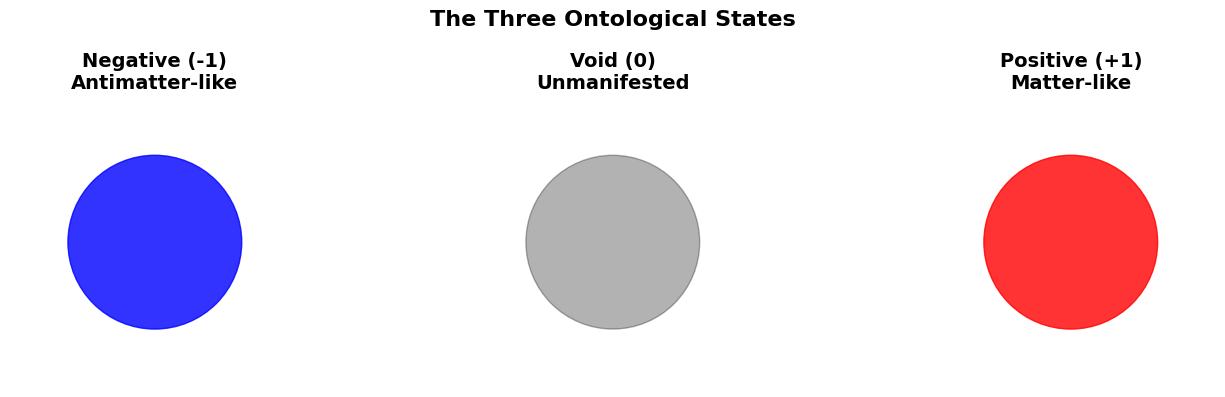

In [18]:
# Create a simple visualization of ternary states
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

states_info = [
    (-1, 'blue', 'Negative (-1)\nAntimatter-like'),
    (0, 'black', 'Void (0)\nUnmanifested'),
    (+1, 'red', 'Positive (+1)\nMatter-like')
]

for ax, (state, color, label) in zip(axes, states_info):
    circle = plt.Circle((0.5, 0.5), 0.3, color=color, alpha=0.8 if state != 0 else 0.3)
    ax.add_patch(circle)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(label, fontsize=14, fontweight='bold')

plt.suptitle('The Three Ontological States', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. The Lattice Universe

The universe is represented as a **3D cubic lattice**. Let's create one and visualize its structure.

In [19]:
# Create a small universe for visualization
CONSTANTS.GRID_SIZE = 16  # Small for visualization
universe = Universe(size=16)

print(f"Universe created!")
print(f"  - Shape: {universe.shape}")
print(f"  - Total voxels: {np.prod(universe.shape):,}")
print(f"  - States dtype: {universe.states.dtype}")
print(f"  - Flux shape: {universe.flux.shape} (includes 3D vector)")

Universe created!
  - Shape: (16, 16, 16)
  - Total voxels: 4,096
  - States dtype: int8
  - Flux shape: (16, 16, 16, 3) (includes 3D vector)


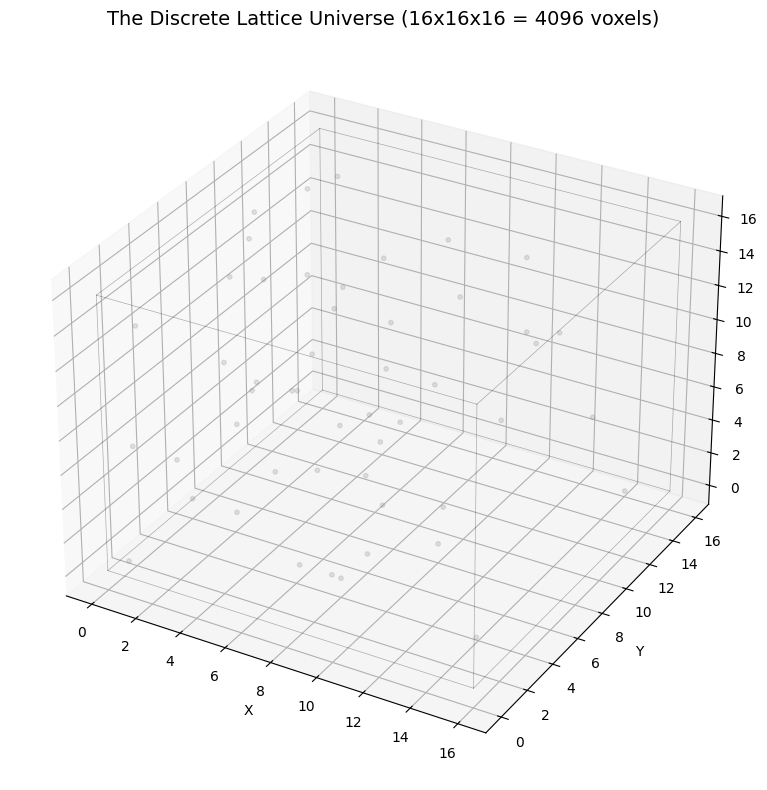

In [20]:
# Visualize the empty lattice structure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a wireframe cube to represent the lattice
size = universe.size

# Draw lattice boundary
for i in [0, size]:
    for j in [0, size]:
        ax.plot([0, size], [i, i], [j, j], 'k-', alpha=0.3, linewidth=0.5)
        ax.plot([i, i], [0, size], [j, j], 'k-', alpha=0.3, linewidth=0.5)
        ax.plot([i, i], [j, j], [0, size], 'k-', alpha=0.3, linewidth=0.5)

# Show some sample voxel positions
sample_points = np.random.choice(size, size=(50, 3))
ax.scatter(sample_points[:,0], sample_points[:,1], sample_points[:,2], 
           c='gray', alpha=0.2, s=10, label='Sample Voxel Positions')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'The Discrete Lattice Universe ({size}x{size}x{size} = {size**3} voxels)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. The Flux Field

While states are discrete ({-1, 0, +1}), the **flux field** J(v,t) is a continuous 3D vector at each voxel.

The flux represents:
- **Energy density** at each point
- **Potential for manifestation** (when |J| > KB)
- **Wave-like propagation** medium

Let's inject some flux and visualize it:

In [21]:
# Create a fresh universe with a flux pulse
universe = Universe(size=32)
center = universe.size // 2

# Inject a spherical Gaussian flux pulse at center
for dx in range(-3, 4):
    for dy in range(-3, 4):
        for dz in range(-3, 4):
            r = np.sqrt(dx**2 + dy**2 + dz**2)
            if r < 4:
                magnitude = 5.0 * np.exp(-r**2 / 2)
                # Random direction
                direction = np.random.randn(3)
                direction /= np.linalg.norm(direction) + 1e-10
                universe.flux[center+dx, center+dy, center+dz] = magnitude * direction

print(f"Flux pulse injected at center ({center}, {center}, {center})")
print(f"Max flux magnitude: {np.max(np.linalg.norm(universe.flux, axis=-1)):.2f}")

Flux pulse injected at center (16, 16, 16)
Max flux magnitude: 5.00


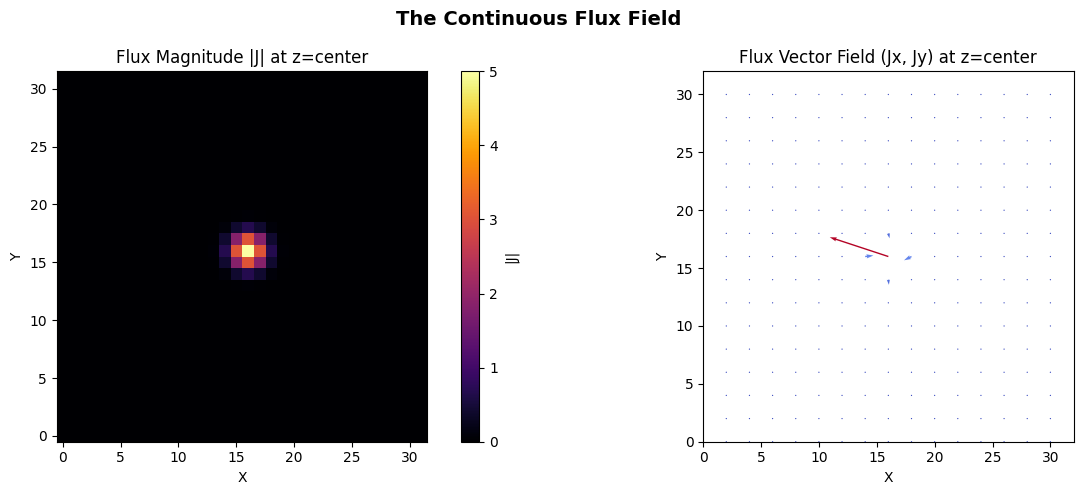

In [22]:
# Visualize flux as a 2D cross-section
mid_z = universe.size // 2
flux_magnitude = np.linalg.norm(universe.flux[:, :, mid_z, :], axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flux magnitude
im1 = axes[0].imshow(flux_magnitude, cmap='inferno', origin='lower')
axes[0].set_title('Flux Magnitude |J| at z=center', fontsize=12)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[0], label='|J|')

# Flux vectors (quiver plot)
# Subsample for clarity
step = 2
X, Y = np.meshgrid(np.arange(0, universe.size, step), np.arange(0, universe.size, step))
Jx = universe.flux[::step, ::step, mid_z, 0]
Jy = universe.flux[::step, ::step, mid_z, 1]

axes[1].quiver(X, Y, Jx, Jy, np.sqrt(Jx**2 + Jy**2), cmap='coolwarm', scale=30)
axes[1].set_xlim(0, universe.size)
axes[1].set_ylim(0, universe.size)
axes[1].set_title('Flux Vector Field (Jx, Jy) at z=center', fontsize=12)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_aspect('equal')

plt.suptitle('The Continuous Flux Field', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. The Update Cycle

Physics evolves through a **12-phase update cycle** (see CLAUDE.md Chapter 5). The main phases are:

1. **Decay** - Unlocked flux dissipates
2. **Manifestation** - Genesis (0 → ±1) and Evaporation (±1 → 0)
3. **Wave Propagation** - Flux evolves via discrete wave equation
4. **Field Computation** - Calculate density, gradients, curl
5. **Interactions** - Collisions, annihilation
6. **Binding** - Detect stable structures

Let's run a few ticks and watch the flux evolve:

In [23]:
# Configure for stable simulation
CONSTANTS.C = 0.5
CONSTANTS.KB = 2.0  # High threshold - prevent genesis for now
CONSTANTS.DECAY_RATE = 0.01
CONSTANTS.DAMPING = 0.02

# Track evolution over time
snapshots = []
times = [0, 5, 10, 20, 40]

for t in range(max(times) + 1):
    if t in times:
        flux_mag = np.linalg.norm(universe.flux[:, :, mid_z, :], axis=-1).copy()
        snapshots.append((t, flux_mag))
    
    master_equation.tick(universe)

print(f"Simulation complete. Captured {len(snapshots)} snapshots.")

Simulation complete. Captured 5 snapshots.


C:\Users\cpaci\AppData\Local\Temp\ipykernel_119348\3753517821.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


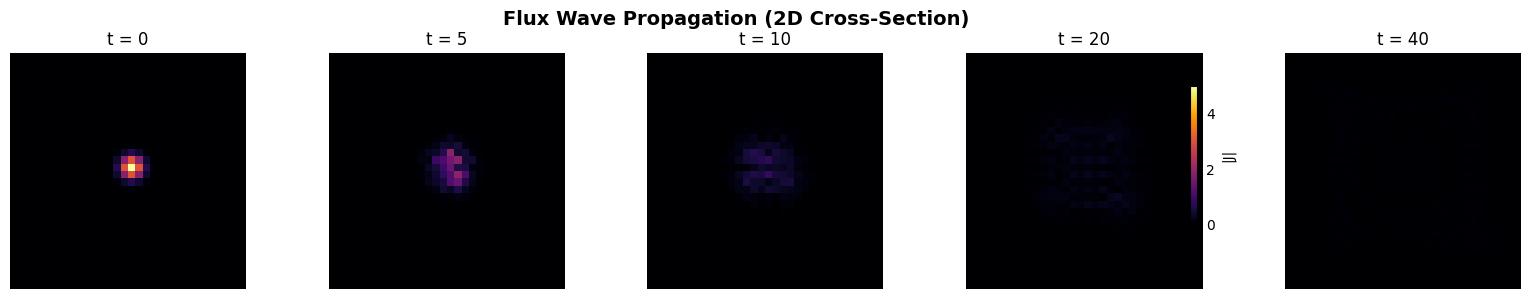

In [24]:
# Visualize flux evolution
fig, axes = plt.subplots(1, len(snapshots), figsize=(16, 3))

# Find global color scale
vmax = max(s[1].max() for s in snapshots)

for ax, (t, flux_mag) in zip(axes, snapshots):
    im = ax.imshow(flux_mag, cmap='inferno', origin='lower', vmin=0, vmax=vmax)
    ax.set_title(f't = {t}')
    ax.axis('off')

plt.suptitle('Flux Wave Propagation (2D Cross-Section)', fontsize=14, fontweight='bold')
fig.colorbar(im, ax=axes, shrink=0.6, label='|J|')
plt.tight_layout()
plt.show()

## 5. Manifestation: Where Physics Meets Ontology

The most fundamental process in FTD is **manifestation** - when flux density exceeds the threshold KB:

```
|J(v)| > KB  →  Void (0) becomes Matter (±1)
```

The **polarity** (+1 or -1) is determined by the sign of the flux divergence ∇·J.

Let's create conditions for manifestation:

In [25]:
# Create a universe with high flux to trigger manifestation
CONSTANTS.KB = 1.0  # Lower threshold
CONSTANTS.DECAY_RATE = 0.001  # Slow decay

universe = Universe(size=32)
center = universe.size // 2

# Inject high-energy flux
universe.flux[center-2:center+2, center-2:center+2, center-2:center+2, :] = 3.0

print(f"High flux region created.")
print(f"Manifestation threshold KB = {CONSTANTS.KB}")
print(f"Max flux: {np.max(np.linalg.norm(universe.flux, axis=-1)):.2f}")

High flux region created.
Manifestation threshold KB = 1.0
Max flux: 5.20


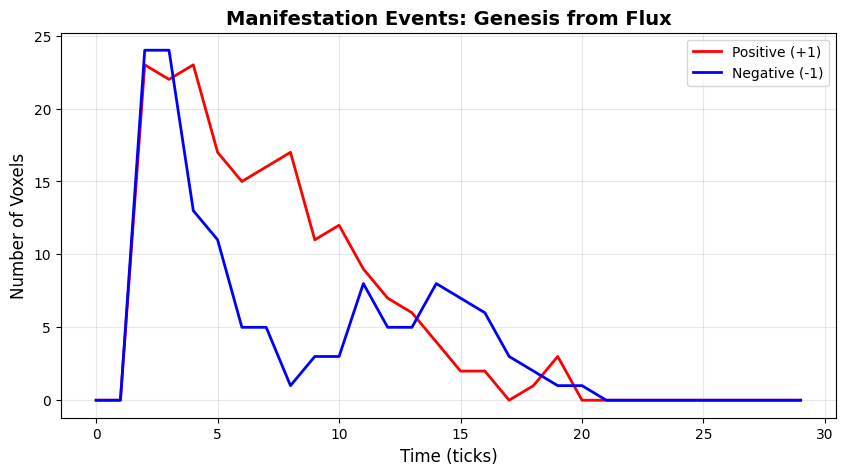


Final state:
  Positive (+1): 0
  Negative (-1): 0


In [26]:
# Run simulation and track manifestation
state_history = []

for t in range(30):
    n_positive = np.count_nonzero(universe.states == 1)
    n_negative = np.count_nonzero(universe.states == -1)
    n_void = np.count_nonzero(universe.states == 0)
    state_history.append((t, n_positive, n_negative, n_void))
    
    master_equation.tick(universe)

# Plot state populations
history = np.array(state_history)

plt.figure(figsize=(10, 5))
plt.plot(history[:, 0], history[:, 1], 'r-', linewidth=2, label='Positive (+1)')
plt.plot(history[:, 0], history[:, 2], 'b-', linewidth=2, label='Negative (-1)')
plt.xlabel('Time (ticks)', fontsize=12)
plt.ylabel('Number of Voxels', fontsize=12)
plt.title('Manifestation Events: Genesis from Flux', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal state:")
print(f"  Positive (+1): {np.count_nonzero(universe.states == 1)}")
print(f"  Negative (-1): {np.count_nonzero(universe.states == -1)}")

## 6. The Framework Constants

FTD derives physical constants from mathematical principles. The key derivation involves the **lemniscatic constant G***:

In [27]:
from scipy.special import gamma

# The Lemniscatic Constant
G_star = np.sqrt(2) * gamma(0.25)**2 / (2 * np.pi)
print(f"Lemniscatic Constant G* = {G_star:.6f}")

# The Master Quadratic
# x² - 16(G*)²x + 16(G*)³ = 0
a = 1
b = -16 * G_star**2
c = 16 * G_star**3

x_plus = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
x_minus = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)

print(f"\nMaster Quadratic Roots:")
print(f"  x₊ = {x_plus:.6f}  →  1/α = 137.036 (fine structure constant)")
print(f"  x₋ = {x_minus:.6f}   →  Nₖ ≈ 3 (color charges)")

# Experimental value
alpha_experimental = 1 / 137.035999177
error_ppm = abs(1/x_plus - alpha_experimental) / alpha_experimental * 1e6
print(f"\nComparison with experiment:")
print(f"  Derived 1/α = {x_plus:.6f}")
print(f"  CODATA 1/α = 137.035999")
print(f"  Error: {error_ppm:.2f} ppm")

Lemniscatic Constant G* = 2.958675

Master Quadratic Roots:
  x₊ = 137.036171  →  1/α = 137.036 (fine structure constant)
  x₋ = 3.023964   →  Nₖ ≈ 3 (color charges)

Comparison with experiment:
  Derived 1/α = 137.036171
  CODATA 1/α = 137.035999
  Error: 1.26 ppm


## 7. What's Next?

This introduction covered the basics. The following notebooks explore deeper:

| Notebook | Topic |
|----------|-------|
| `01_void_and_flux.ipynb` | Wave propagation and flux dynamics |
| `02_manifestation.ipynb` | Genesis and evaporation in detail |
| `03_forces_and_fields.ipynb` | Discrete operators and forces |
| `04_binding_structures.ipynb` | Triads and stable configurations |
| `05_quantum_phenomena.ipynb` | Interference and Born rule |
| `06_constants_derivation.ipynb` | G*, α, and mass predictions |
| `07_verification_suite.ipynb` | Running verification tests |

---

**Key Insight**: FTD shows that discrete, local, deterministic rules can give rise to the rich phenomena we observe in physics - from wave propagation to particle formation to quantum-like behavior.

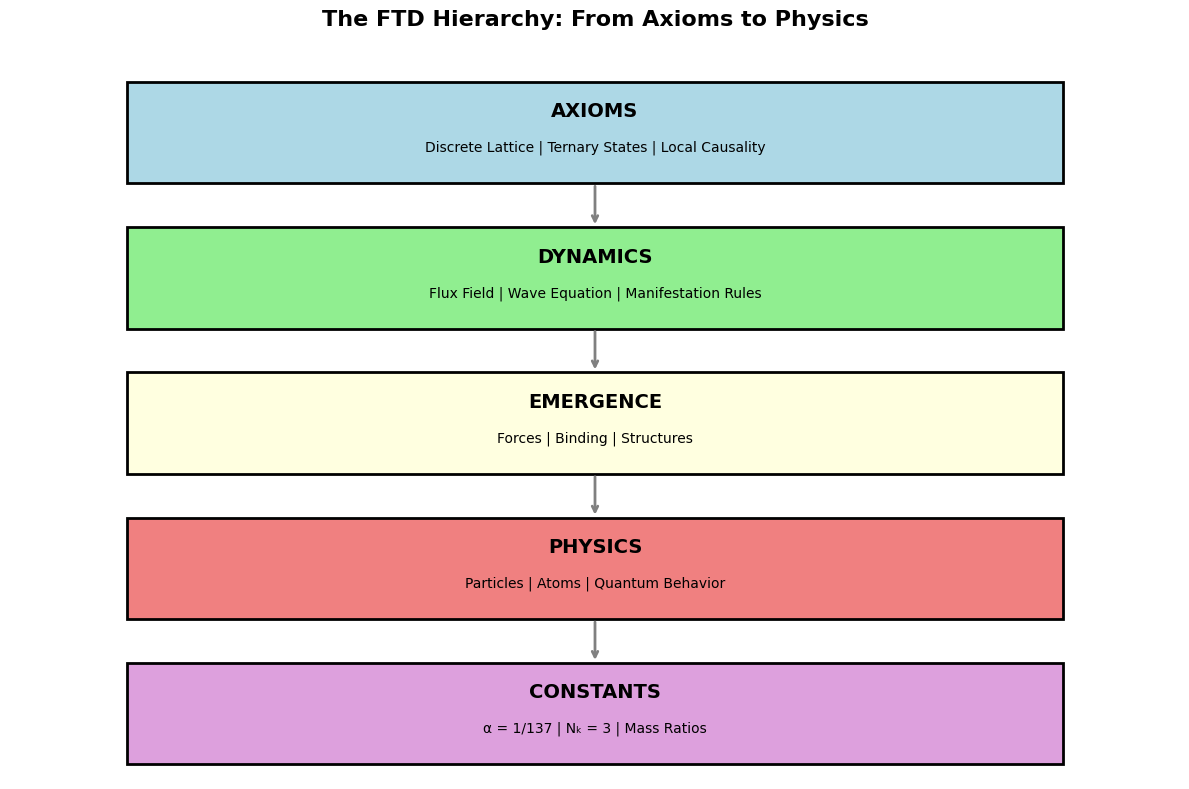

In [28]:
# Summary visualization: The TRD Hierarchy
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

levels = [
    (0.5, 0.9, 'AXIOMS', 'Discrete Lattice | Ternary States | Local Causality', 'lightblue'),
    (0.5, 0.7, 'DYNAMICS', 'Flux Field | Wave Equation | Manifestation Rules', 'lightgreen'),
    (0.5, 0.5, 'EMERGENCE', 'Forces | Binding | Structures', 'lightyellow'),
    (0.5, 0.3, 'PHYSICS', 'Particles | Atoms | Quantum Behavior', 'lightcoral'),
    (0.5, 0.1, 'CONSTANTS', 'α = 1/137 | Nₖ = 3 | Mass Ratios', 'plum'),
]

for x, y, title, desc, color in levels:
    box = plt.Rectangle((0.1, y-0.08), 0.8, 0.14, facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(box)
    ax.text(x, y+0.02, title, ha='center', va='center', fontsize=14, fontweight='bold')
    ax.text(x, y-0.03, desc, ha='center', va='center', fontsize=10)

# Arrows
for i in range(len(levels)-1):
    ax.annotate('', xy=(0.5, levels[i+1][1]+0.06), xytext=(0.5, levels[i][1]-0.08),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('The FTD Hierarchy: From Axioms to Physics', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---

## Navigation

**← Previous:** Start of series  
**→ Next:** [01_void_and_flux.ipynb](01_void_and_flux.ipynb) - Wave propagation and flux dynamics

### Notebook Series

| # | Notebook | Topic |
|---|----------|-------|
| **0** | **00_introduction.ipynb** (current) | Introduction to FTD |
| 1 | 01_void_and_flux.ipynb | Wave propagation |
| 2 | 02_manifestation.ipynb | Genesis and evaporation |
| 3 | 03_forces_and_fields.ipynb | Discrete operators |
| 4 | 04_binding_structures.ipynb | Triads and binding |
| 5 | 05_quantum_phenomena.ipynb | Quantum behavior |
| 6 | 06_constants_derivation.ipynb | Deriving α, masses |
| 7 | 07_verification_suite.ipynb | Verification tests |

### Supplementary Notebooks
- `interactive_universe.ipynb` - Interactive sandbox
- `genesis_to_atoms.ipynb` - Nucleosynthesis simulation
- `genesis_to_chemistry.ipynb` - Molecular structures